# Day 3 — Baseline 모델 학습과 최종 시험 평가

이 노트북은 Day 2에서 정한 데이터 선정 규칙을 공식 BBBP 데이터부터 다시 재현하고, stratified 80:20 train-test split을 수행합니다. 이후 세 가지 단순 모델을 학습하고 봉인한 test set에서 한 번 최종 평가합니다.

사용 모델은 DummyClassifier, 8개 descriptor 기반 Logistic Regression, Morgan fingerprint 기반 Random Forest입니다. 복잡한 튜닝이나 다른 모델은 사용하지 않습니다.

## 1. 실험 규칙을 먼저 고정하기

모델 결과를 본 뒤 설정을 바꾸면 test set에 맞춘 선택이 되어 성능을 과대평가할 수 있습니다. 따라서 실행 전에 다음 규칙을 고정합니다.

- split: stratified 80:20, `random_state=42`
- positive class: BBB+ (`p_np=1`)
- DummyClassifier: 가장 많은 클래스를 항상 예측
- Logistic Regression: StandardScaler + 기본 L2 Logistic Regression, `max_iter=1000`
- Random Forest: 300개 tree, `random_state=42`, 별도 튜닝 없음
- test set: 학습과 설정 선택에는 사용하지 않고 마지막 평가에서만 예측

**입력:** 설치된 Python·분석 라이브러리와 프로젝트 경로입니다.  
**출력:** 실제 실행 버전과 결과 저장 폴더를 출력합니다.

In [1]:
from pathlib import Path
import io
import logging
import os
import re
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "results"
WORK_DIR = PROJECT_ROOT / "work"
RESULTS_DIR.mkdir(exist_ok=True)
WORK_DIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(WORK_DIR / "matplotlib-cache"))

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rdkit
import seaborn as sns
import sklearn
from IPython.display import display
from rdkit import Chem, DataStructs, rdBase
from rdkit.Chem import Crippen, Descriptors, Lipinski, rdFingerprintGenerator, rdMolDescriptors
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 120)

versions = pd.Series(
    {
        "Python": sys.version.split()[0],
        "NumPy": np.__version__,
        "pandas": pd.__version__,
        "RDKit": rdkit.__version__,
        "scikit-learn": sklearn.__version__,
        "Matplotlib": matplotlib.__version__,
        "seaborn": sns.__version__,
    },
    name="version",
)
display(versions.to_frame())
print(f"프로젝트 루트: {PROJECT_ROOT}")
print(f"결과 폴더: {RESULTS_DIR}")

,version
Python,3.12.13
NumPy,2.5.2
pandas,3.0.5
RDKit,2026.03.5
scikit-learn,1.9.0
Matplotlib,3.11.1
seaborn,0.13.2


프로젝트 루트: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp
결과 폴더: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp\results


## 2. Day 2의 최종 모델용 데이터 재현

**입력:** Day 1·2와 동일한 공식 DeepChem BBBP CSV URL입니다.  
**출력:** 원본 2,050행에서 RDKit 파싱 실패 11행, 동일 라벨 중복 초과 54행, 라벨 충돌 20행을 모델 대상에서 제외해 canonical SMILES가 서로 다른 최종 1,965행을 만듭니다.

Day 2 결과 CSV를 학습 데이터로 읽지 않고 같은 규칙을 코드로 재실행합니다. 원본 DataFrame에서는 어떤 행도 삭제하지 않으며, 오류 로그도 전체 비활성화하지 않고 행별로 수집합니다.

In [2]:
DATA_URL = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv"
original_df = pd.read_csv(DATA_URL)
original_df["source_index"] = original_df.index

rdBase.LogToPythonLogger()
rdkit_logger = logging.getLogger("rdkit")
rdkit_logger.setLevel(logging.ERROR)
original_log_handlers = rdkit_logger.handlers[:]
for existing_handler in original_log_handlers:
    rdkit_logger.removeHandler(existing_handler)

def parse_smiles_with_reason(smiles):
    """SMILES를 RDKit Mol로 변환하고 실패 이유를 함께 반환합니다."""
    if pd.isna(smiles):
        return None, "SMILES 값이 비어 있습니다."
    log_stream = io.StringIO()
    log_handler = logging.StreamHandler(log_stream)
    log_handler.setLevel(logging.ERROR)
    rdkit_logger.addHandler(log_handler)
    try:
        mol = Chem.MolFromSmiles(str(smiles))
    except Exception as exc:
        mol = None
        log_stream.write(f"{type(exc).__name__}: {exc}")
    finally:
        rdkit_logger.removeHandler(log_handler)
    messages = []
    for line in log_stream.getvalue().splitlines():
        cleaned = re.sub(r"^\[\d{2}:\d{2}:\d{2}\]\s*", "", line.strip())
        if cleaned:
            messages.append(cleaned)
    error_message = " | ".join(messages)
    if mol is None and not error_message:
        error_message = "RDKit이 분자 객체를 반환하지 않았습니다."
    return mol, error_message

parse_results = original_df["smiles"].map(parse_smiles_with_reason)
audit_df = original_df.copy()
audit_df["mol"] = parse_results.map(lambda result: result[0])
audit_df["parse_error"] = parse_results.map(lambda result: result[1])
audit_df["parse_ok"] = audit_df["mol"].notna()
for original_handler in original_log_handlers:
    rdkit_logger.addHandler(original_handler)

candidate_df = audit_df.loc[audit_df["parse_ok"]].copy()
candidate_df["canonical_smiles"] = candidate_df["mol"].map(
    lambda mol: Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
)
group_label_counts = candidate_df.groupby("canonical_smiles")["p_np"].nunique()
conflicting_keys = set(group_label_counts.loc[group_label_counts > 1].index)
without_conflicts_df = candidate_df.loc[
    ~candidate_df["canonical_smiles"].isin(conflicting_keys)
].copy()
final_model_df = (
    without_conflicts_df.sort_values("source_index")
    .drop_duplicates(subset="canonical_smiles", keep="first")
    .reset_index(drop=True)
)

original_count = len(original_df)
parse_failure_count = int((~audit_df["parse_ok"]).sum())
conflicting_rows_excluded = int(candidate_df["canonical_smiles"].isin(conflicting_keys).sum())
same_label_duplicate_excluded = len(candidate_df) - conflicting_rows_excluded - len(final_model_df)

assert original_count == 2050
assert parse_failure_count == 11
assert conflicting_rows_excluded == 20
assert same_label_duplicate_excluded == 54
assert len(final_model_df) == 1965
assert final_model_df["canonical_smiles"].is_unique
assert original_count == parse_failure_count + same_label_duplicate_excluded + conflicting_rows_excluded + len(final_model_df)

print("Day 2 정제 규칙 재현 완료")
print(f"{original_count:,} = {parse_failure_count:,} + {same_label_duplicate_excluded:,} + {conflicting_rows_excluded:,} + {len(final_model_df):,}")

Day 2 정제 규칙 재현 완료
2,050 = 11 + 54 + 20 + 1,965


## 3. Stratified 80:20 train-test split

**입력:** canonical SMILES가 서로 다른 최종 모델용 1,965행과 `p_np` 라벨입니다.  
**출력:** 학습용 80%와 시험용 20%를 만들고 클래스 비율과 구조 중복이 없는지 검증합니다. 요약은 `day3_split_summary.csv`에 저장합니다.

`stratify`는 BBB+와 BBB-의 비율이 train과 test에서 거의 같도록 합니다. 중복 구조를 split 전에 처리했으므로 같은 canonical SMILES가 양쪽에 들어가는 누출도 방지합니다. 이 단계에서는 test 성능을 계산하거나 모델 설정을 바꾸지 않습니다.

In [3]:
RANDOM_STATE = 42
TEST_SIZE = 0.20

train_df, test_df = train_test_split(
    final_model_df,
    test_size=TEST_SIZE,
    stratify=final_model_df["p_np"],
    random_state=RANDOM_STATE,
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
y_train = train_df["p_np"].to_numpy()
y_test = test_df["p_np"].to_numpy()

assert len(train_df) + len(test_df) == len(final_model_df)
assert set(train_df["canonical_smiles"]).isdisjoint(set(test_df["canonical_smiles"]))
assert set(np.unique(y_train)) == {0, 1}
assert set(np.unique(y_test)) == {0, 1}

def summarize_split(name, frame):
    counts = frame["p_np"].value_counts()
    return {
        "split": name,
        "rows": len(frame),
        "BBB-_count": int(counts.get(0, 0)),
        "BBB-_percent": round(counts.get(0, 0) / len(frame) * 100, 2),
        "BBB+_count": int(counts.get(1, 0)),
        "BBB+_percent": round(counts.get(1, 0) / len(frame) * 100, 2),
    }

split_summary = pd.DataFrame(
    [
        summarize_split("full", final_model_df),
        summarize_split("train", train_df),
        summarize_split("test", test_df),
    ]
)
split_summary_path = RESULTS_DIR / "day3_split_summary.csv"
split_summary.to_csv(split_summary_path, index=False, encoding="utf-8")
display(split_summary)
print("Train과 test 사이 canonical SMILES 중복: 0개")

,split,rows,BBB-_count,BBB-_percent,BBB+_count,BBB+_percent
0,full,1965,465,23.66,1500,76.34
1,train,1572,372,23.66,1200,76.34
2,test,393,93,23.66,300,76.34


Train과 test 사이 canonical SMILES 중복: 0개


## 4. Train과 test 특성을 각각 생성

**입력:** 분할이 끝난 train과 test의 RDKit 분자입니다.  
**출력:** 각 split에 대해 8개 descriptor와 2,048-bit Morgan fingerprint 행렬을 따로 생성하고 shape·결측값·0/1 여부를 검사합니다.

Descriptor와 fingerprint 계산은 학습되는 통계가 없는 결정적 변환입니다. 반면 평균과 표준편차를 학습하는 `StandardScaler`는 뒤의 Logistic Regression 파이프라인 내부에서 train에만 `fit`됩니다.

In [4]:
DESCRIPTOR_NAMES = [
    "MolWt", "MolLogP", "TPSA", "NumHDonors",
    "NumHAcceptors", "NumRotatableBonds", "RingCount", "FractionCSP3",
]
MORGAN_RADIUS = 2
MORGAN_FP_SIZE = 2048

def calculate_descriptors(mol):
    return {
        "MolWt": Descriptors.MolWt(mol),
        "MolLogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "NumHDonors": Lipinski.NumHDonors(mol),
        "NumHAcceptors": Lipinski.NumHAcceptors(mol),
        "NumRotatableBonds": Lipinski.NumRotatableBonds(mol),
        "RingCount": Lipinski.RingCount(mol),
        "FractionCSP3": Descriptors.FractionCSP3(mol),
    }

def descriptor_matrix(molecules):
    return pd.DataFrame(
        [calculate_descriptors(mol) for mol in molecules],
        columns=DESCRIPTOR_NAMES,
    )

def generate_morgan_matrix(molecules, radius=2, fp_size=2048):
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=fp_size)
    matrix = np.zeros((len(molecules), fp_size), dtype=np.uint8)
    for row_index, mol in enumerate(molecules):
        fingerprint = generator.GetFingerprint(mol)
        row = np.zeros(fp_size, dtype=np.uint8)
        DataStructs.ConvertToNumpyArray(fingerprint, row)
        matrix[row_index] = row
    return matrix

X_train_descriptors = descriptor_matrix(train_df["mol"].tolist())
X_test_descriptors = descriptor_matrix(test_df["mol"].tolist())
X_train_morgan = generate_morgan_matrix(train_df["mol"].tolist(), MORGAN_RADIUS, MORGAN_FP_SIZE)
X_test_morgan = generate_morgan_matrix(test_df["mol"].tolist(), MORGAN_RADIUS, MORGAN_FP_SIZE)

assert X_train_descriptors.shape == (len(train_df), 8)
assert X_test_descriptors.shape == (len(test_df), 8)
assert np.isfinite(X_train_descriptors.to_numpy()).all()
assert np.isfinite(X_test_descriptors.to_numpy()).all()
assert X_train_morgan.shape == (len(train_df), 2048)
assert X_test_morgan.shape == (len(test_df), 2048)
assert set(np.unique(X_train_morgan).tolist()).issubset({0, 1})
assert set(np.unique(X_test_morgan).tolist()).issubset({0, 1})

feature_shapes = pd.DataFrame(
    {
        "matrix": ["train descriptors", "test descriptors", "train Morgan", "test Morgan"],
        "shape": [
            str(X_train_descriptors.shape), str(X_test_descriptors.shape),
            str(X_train_morgan.shape), str(X_test_morgan.shape),
        ],
    }
)
display(feature_shapes)

,matrix,shape
0,train descriptors,"(1572, 8)"
1,test descriptors,"(393, 8)"
2,train Morgan,"(1572, 2048)"
3,test Morgan,"(393, 2048)"


## 5. 세 모델을 고정된 설정으로 정의

**입력:** 실행 전에 정한 단순 설정입니다.  
**출력:** 세 모델 객체와 설정 비교표를 만듭니다. 아직 test set을 사용하지 않습니다.

DummyClassifier는 다수 클래스만 예측하는 기준선입니다. Logistic Regression은 크기가 다른 descriptor를 공정하게 사용하도록 StandardScaler와 하나의 Pipeline으로 묶습니다. Random Forest는 2,048-bit Morgan fingerprint의 비선형 구조 패턴을 사용합니다.

In [5]:
dummy_model = DummyClassifier(strategy="most_frequent")
logistic_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]
)
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model_settings = pd.DataFrame(
    [
        {"model": "DummyClassifier", "features": "입력을 무시함", "fixed_setting": "strategy=most_frequent"},
        {"model": "Logistic Regression", "features": "8 RDKit descriptors", "fixed_setting": "StandardScaler, max_iter=1000"},
        {"model": "Random Forest", "features": "Morgan radius=2, 2048 bits", "fixed_setting": "n_estimators=300"},
    ]
)
display(model_settings)
print("하이퍼파라미터 탐색은 수행하지 않습니다.")

,model,features,fixed_setting
0,DummyClassifier,입력을 무시함,strategy=most_frequent
1,Logistic Regression,8 RDKit descriptors,"StandardScaler, max_iter=1000"
2,Random Forest,"Morgan radius=2, 2048 bits",n_estimators=300


하이퍼파라미터 탐색은 수행하지 않습니다.


## 6. Train 데이터만 사용해 학습

**입력:** train descriptor, train Morgan fingerprint와 `y_train`입니다.  
**출력:** 학습이 끝난 세 모델을 만듭니다. 이 셀에서는 `X_test`와 `y_test`를 모델에 전달하지 않습니다.

Logistic Regression 파이프라인의 scaler도 이 `fit` 호출 안에서 train descriptor의 평균과 표준편차만 학습합니다. 이것이 test 정보가 전처리에 들어가는 데이터 누출을 막습니다.

In [6]:
dummy_model.fit(X_train_descriptors, y_train)
logistic_model.fit(X_train_descriptors, y_train)
random_forest_model.fit(X_train_morgan, y_train)

assert hasattr(dummy_model, "classes_")
assert hasattr(logistic_model.named_steps["scaler"], "mean_")
assert hasattr(random_forest_model, "classes_")
assert len(logistic_model.named_steps["scaler"].mean_) == 8
print("세 모델의 train-only 학습이 완료되었습니다.")
print("아직 test 예측은 수행하지 않았습니다.")

세 모델의 train-only 학습이 완료되었습니다.
아직 test 예측은 수행하지 않았습니다.


## 7. 봉인한 test set에서 한 번 최종 평가

**입력:** 학습이 끝난 세 모델과 각 모델에 맞는 test 특성입니다.  
**출력:** test 예측을 한 번 생성해 Accuracy, F1-score, ROC-AUC를 계산하고 `day3_model_metrics.csv`에 저장합니다. 이후 그림은 여기서 만든 동일한 예측을 재사용합니다.

- Accuracy: 전체 예측 중 맞춘 비율
- F1-score: BBB+에 대한 precision과 recall의 조화평균
- ROC-AUC: 분류 임계값 전체에서 BBB+를 BBB-보다 높게 점수화하는 능력

클래스가 불균형하므로 Accuracy 하나만 보지 않고 세 지표를 함께 봅니다.

In [7]:
evaluation_specs = [
    ("DummyClassifier", "입력을 무시함", dummy_model, X_test_descriptors),
    ("Logistic Regression", "8 RDKit descriptors", logistic_model, X_test_descriptors),
    ("Random Forest", "Morgan radius=2, 2048 bits", random_forest_model, X_test_morgan),
]

evaluation_artifacts = {}
metric_rows = []
for model_name, feature_name, model, X_test_for_model in evaluation_specs:
    y_prediction = model.predict(X_test_for_model)
    positive_column = int(np.where(model.classes_ == 1)[0][0])
    y_probability = model.predict_proba(X_test_for_model)[:, positive_column]
    matrix = confusion_matrix(y_test, y_prediction, labels=[0, 1])
    fpr, tpr, _ = roc_curve(y_test, y_probability, pos_label=1)
    accuracy = accuracy_score(y_test, y_prediction)
    f1 = f1_score(y_test, y_prediction, pos_label=1, zero_division=0)
    auc = roc_auc_score(y_test, y_probability)
    metric_rows.append(
        {
            "model": model_name,
            "feature_set": feature_name,
            "accuracy": accuracy,
            "f1_score": f1,
            "roc_auc": auc,
        }
    )
    evaluation_artifacts[model_name] = {
        "prediction": y_prediction,
        "probability": y_probability,
        "confusion_matrix": matrix,
        "fpr": fpr,
        "tpr": tpr,
        "roc_auc": auc,
    }

model_metrics = pd.DataFrame(metric_rows)
model_metrics[["accuracy", "f1_score", "roc_auc"]] = model_metrics[
    ["accuracy", "f1_score", "roc_auc"]
].round(4)
metrics_path = RESULTS_DIR / "day3_model_metrics.csv"
model_metrics.to_csv(metrics_path, index=False, encoding="utf-8")

assert model_metrics.shape == (3, 5)
assert np.isfinite(model_metrics[["accuracy", "f1_score", "roc_auc"]].to_numpy()).all()
assert ((model_metrics[["accuracy", "f1_score", "roc_auc"]] >= 0) & (model_metrics[["accuracy", "f1_score", "roc_auc"]] <= 1)).all().all()
test_evaluation_complete = True
display(model_metrics)
print(f"저장 위치: {metrics_path}")

,model,feature_set,accuracy,f1_score,roc_auc
0,DummyClassifier,입력을 무시함,0.7634,0.8658,0.5000
1,Logistic Regression,8 RDKit descriptors,0.8550,0.9100,0.8475
2,Random Forest,"Morgan radius=2, 2048 bits",0.8830,0.9274,0.8960


저장 위치: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp\results\day3_model_metrics.csv


## 8. Confusion matrix 비교

**입력:** 앞 평가 셀에서 이미 만든 세 모델의 test 예측입니다.  
**출력:** 실제 BBB-/BBB+와 예측 BBB-/BBB+의 조합을 세 confusion matrix로 그리고 `day3_confusion_matrices.png`에 저장합니다. test 모델 예측을 새로 만들지 않고 기존 결과를 재사용합니다.

행은 실제 클래스, 열은 예측 클래스입니다. 왼쪽 위와 오른쪽 아래는 정답이고 나머지는 오류입니다.

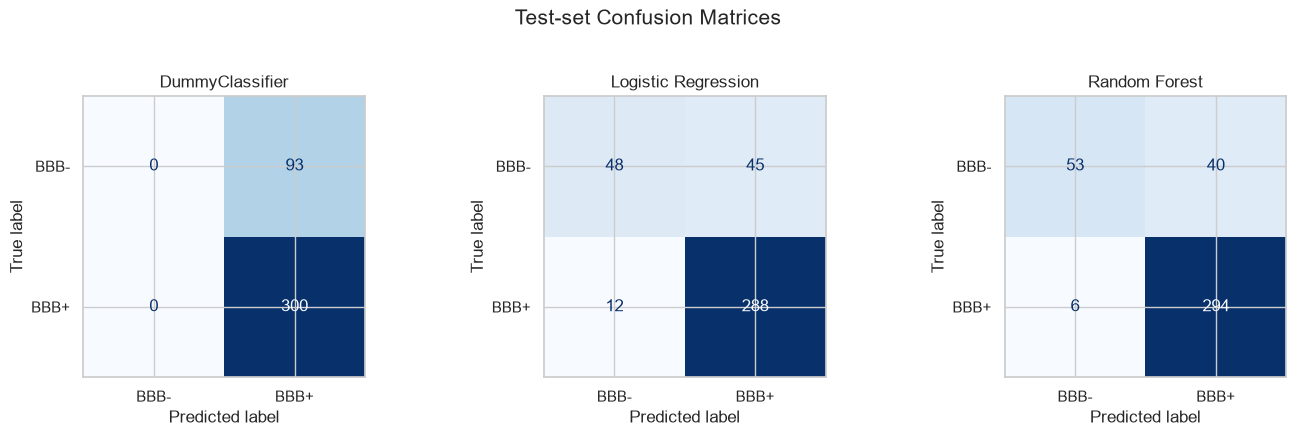

저장 위치: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp\results\day3_confusion_matrices.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for axis, model_name in zip(axes, ["DummyClassifier", "Logistic Regression", "Random Forest"]):
    ConfusionMatrixDisplay(
        confusion_matrix=evaluation_artifacts[model_name]["confusion_matrix"],
        display_labels=["BBB-", "BBB+"],
    ).plot(ax=axis, cmap="Blues", colorbar=False, values_format="d")
    axis.set_title(model_name)

fig.suptitle("Test-set Confusion Matrices", fontsize=15, y=1.03)
fig.tight_layout()
confusion_path = RESULTS_DIR / "day3_confusion_matrices.png"
fig.savefig(confusion_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"저장 위치: {confusion_path}")

## 9. ROC curve 비교

**입력:** 앞 평가 셀에서 이미 계산한 BBB+ 확률과 ROC 좌표입니다.  
**출력:** 세 모델의 ROC curve와 AUC를 한 그림에 표시해 `day3_roc_curves.png`에 저장합니다. 대각선은 무작위 순위 수준인 AUC 0.5를 나타냅니다.

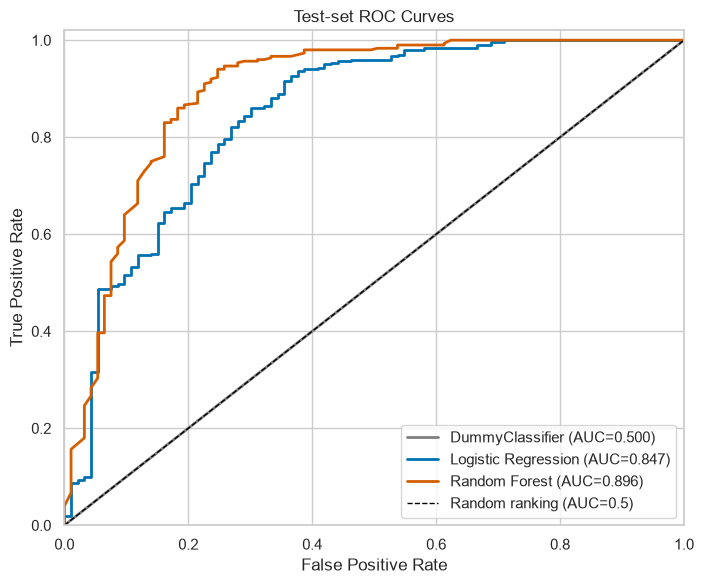

저장 위치: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp\results\day3_roc_curves.png


In [9]:
model_colors = {
    "DummyClassifier": "#7F7F7F",
    "Logistic Regression": "#0072B2",
    "Random Forest": "#D55E00",
}
fig, axis = plt.subplots(figsize=(7.2, 6))
for model_name in ["DummyClassifier", "Logistic Regression", "Random Forest"]:
    artifact = evaluation_artifacts[model_name]
    axis.plot(
        artifact["fpr"], artifact["tpr"], linewidth=2, color=model_colors[model_name],
        label=f"{model_name} (AUC={artifact['roc_auc']:.3f})",
    )
axis.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1, label="Random ranking (AUC=0.5)")
axis.set_xlabel("False Positive Rate")
axis.set_ylabel("True Positive Rate")
axis.set_title("Test-set ROC Curves")
axis.set_xlim(0, 1)
axis.set_ylim(0, 1.02)
axis.legend(loc="lower right")
fig.tight_layout()
roc_path = RESULTS_DIR / "day3_roc_curves.png"
fig.savefig(roc_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"저장 위치: {roc_path}")

### Test 결과에서 관찰한 사실

아래 내용은 이 한 번의 stratified random split에서 관찰한 결과이며, 특정 표현이나 모델이 항상 더 좋다는 인과적·일반적 결론은 아닙니다.

1. DummyClassifier는 모든 분자를 다수 클래스인 BBB+로 예측해 Accuracy 0.7634와 F1 0.8658을 얻었지만 BBB- 93개를 하나도 맞히지 못했고 ROC-AUC는 0.5000이었습니다.
2. Logistic Regression은 Accuracy 0.8550, F1 0.9100, ROC-AUC 0.8475로 기준모델보다 세 지표 모두 높았습니다. BBB- 93개 중 48개, BBB+ 300개 중 288개를 맞혔습니다.
3. Random Forest는 Accuracy 0.8830, F1 0.9274, ROC-AUC 0.8960으로 이번 비교에서 가장 높았습니다. BBB- 53개와 BBB+ 294개를 맞혔습니다.
4. Dummy의 높은 Accuracy와 F1은 BBB+가 76.34%인 클래스 불균형의 영향을 받으므로, ROC-AUC와 confusion matrix를 함께 보는 것이 중요합니다.

## 10. 최종 검증과 해석 시 주의점

**입력:** split 요약, 세 모델의 test 지표와 생성된 결과 파일입니다.  
**출력:** 실험 핵심 구조와 산출물 존재 여부를 검사하고 완료 메시지를 출력합니다.

이 결과는 한 번의 stratified random split에서 얻은 미니 프로젝트 baseline입니다. 화학적으로 비슷한 scaffold가 train과 test에 나뉠 수 있어 scaffold split보다 낙관적일 수 있고, 외부 데이터 검증·확률 보정·하이퍼파라미터 탐색도 하지 않았습니다. 따라서 임상적 판단이나 실제 약물 개발 성능으로 해석하면 안 됩니다.

In [10]:
required_outputs = [split_summary_path, metrics_path, confusion_path, roc_path]
assert test_evaluation_complete
assert all(path.exists() for path in required_outputs)
assert len(train_df) == 1572
assert len(test_df) == 393
assert set(train_df["canonical_smiles"]).isdisjoint(set(test_df["canonical_smiles"]))
assert not (PROJECT_ROOT / "BBBP.csv").exists()

completion_summary = pd.DataFrame(
    [
        {"항목": "최종 모델용 분자", "값": len(final_model_df)},
        {"항목": "Train 분자", "값": len(train_df)},
        {"항목": "Test 분자", "값": len(test_df)},
        {"항목": "Train-test canonical 중복", "값": 0},
        {"항목": "평가 모델 수", "값": len(model_metrics)},
        {"항목": "생성된 Day 3 결과 파일", "값": len(required_outputs)},
    ]
)
display(completion_summary)
print("Day 3 검증 통과: train-only 학습 후 봉인한 test set을 한 번 평가했습니다.")
print("하이퍼파라미터 탐색, GNN, Transformer, XGBoost는 사용하지 않았습니다.")

,항목,값
0,최종 모델용 분자,1965
1,Train 분자,1572
2,Test 분자,393
3,Train-test canonical 중복,0
4,평가 모델 수,3
5,생성된 Day 3 결과 파일,4


Day 3 검증 통과: train-only 학습 후 봉인한 test set을 한 번 평가했습니다.
하이퍼파라미터 탐색, GNN, Transformer, XGBoost는 사용하지 않았습니다.
